initial setup

Random Forest
{'MAE': 1.5666049940212494, 'RMSE': np.float64(3.2179467495034983), 'R2': 0.99570592921163}

XGBoost
{'MAE': 1.0956031956151129, 'RMSE': np.float64(5.409904349910372), 'R2': 0.9878635780706867}

Final Comparison:
                     MAE      RMSE        R2
Random Forest  1.566605  3.217947  0.995706
XGBoost        1.095603  5.409904  0.987864

Best Model: Random Forest


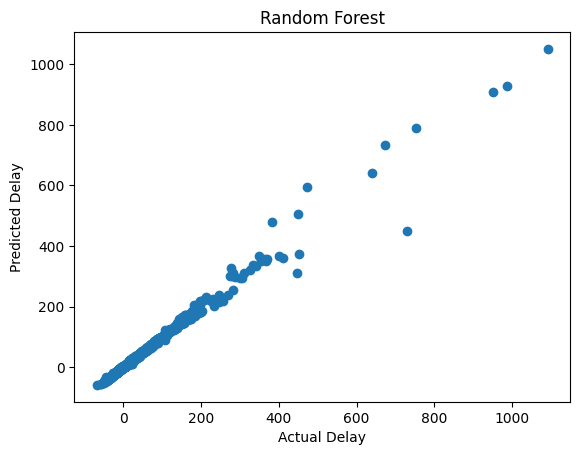

In [54]:
print("initial setup")


# =============================
# IMPORTS
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# =============================
# LOAD DATASET
# =============================
df = pd.read_csv('/kaggle/input/datasets/kesinisoujanya/airline-flight-delay-dataset-100k-records/flights.csv')

# =============================
# CLEAN COLUMN NAMES
# =============================
df.columns = df.columns.str.strip().str.lower()

# =============================
# 🔥 DROP USELESS COLUMNS (FIXED)
# =============================
df = df.drop(columns=['unnamed: 27', 'cancellation_code'], errors='ignore')

# =============================
# REMOVE DUPLICATES
# =============================
df = df.drop_duplicates()

# =============================
# REMOVE INVALID ROWS
# =============================
df = df[df['cancelled'] == 0]
df = df[df['diverted'] == 0]

# =============================
# REMOVE MISSING TARGET
# =============================
df = df.dropna(subset=['arr_delay'])

# =============================
# OPTIONAL: SPEED UP (sample data)
# =============================
df = df.sample(30000, random_state=42)

# =============================
# TARGET
# =============================
target = 'arr_delay'

# =============================
# FEATURE ENGINEERING
# =============================

# Date features
df['fl_date'] = pd.to_datetime(df['fl_date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['fl_date'])

df['day_of_week'] = df['fl_date'].dt.dayofweek
df['month'] = df['fl_date'].dt.month

# Time features
df['dep_hour'] = df['crs_dep_time'] // 100

# Flags
df['is_peak_season'] = df['month'].isin([6, 7, 12]).astype(int)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Strong feature
df['delay_diff'] = df['arr_delay'] - df['dep_delay']

# Drop original date
df = df.drop(columns=['fl_date'], errors='ignore')

# =============================
# REMOVE DATA LEAKAGE
# =============================
df = df.drop(columns=[
    'arr_time',
    'wheels_on',
    'actual_elapsed_time',
    'air_time'
], errors='ignore')

# =============================
# FEATURES & TARGET
# =============================
X = df.drop(columns=[target])
y = df[target]

# =============================
# COLUMN TYPES
# =============================
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

# =============================
# PREPROCESSING
# =============================
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

# =============================
# SPLIT
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# METRICS
# =============================
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

# =============================
# MODELS (FAST VERSION)
# =============================
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=50,   # 🔻 reduced
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ),
    
    "XGBoost": XGBRegressor(
        n_estimators=100,  # 🔻 reduced
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
}

# =============================
# TRAIN
# =============================
results = {}

for name, model in models.items():
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    results[name] = evaluate(y_test, y_pred)
    
    print(f"\n{name}")
    print(results[name])

# =============================
# RESULTS
# =============================
results_df = pd.DataFrame(results).T
print("\nFinal Comparison:\n", results_df)

# =============================
# BEST MODEL
# =============================
best_model_name = results_df['R2'].idxmax()
print(f"\nBest Model: {best_model_name}")

# =============================
# VISUALIZATION
# =============================
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title(best_model_name)
plt.show()

Initial setup

RQ1


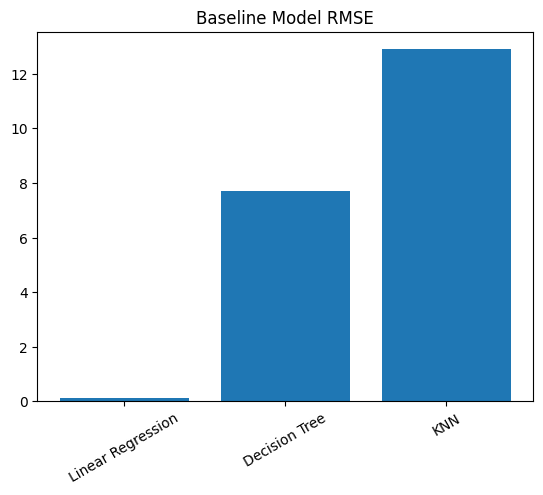

In [55]:
print("RQ1")


# =============================
# MODELS
# =============================
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    metrics = evaluate(y_test, preds)
    metrics['Model'] = name
    results.append(metrics)

df_results = pd.DataFrame(results)
df_results.to_csv("table1_baseline.csv", index=False)

# Plot
plt.figure()
plt.bar(df_results['Model'], df_results['RMSE'])
plt.title("Baseline Model RMSE")
plt.xticks(rotation=30)
plt.savefig("figure1_baseline.pdf")
plt.show()

RQ2
Training Linear Regression...
Training Random Forest...
Training Gradient Boosting...

Model Comparison:
         MAE      RMSE        R2              Model
0  5.620108  7.659450  0.975672  Linear Regression
2  6.698282  8.747341  0.968270  Gradient Boosting
1  6.927459  9.449810  0.962970      Random Forest


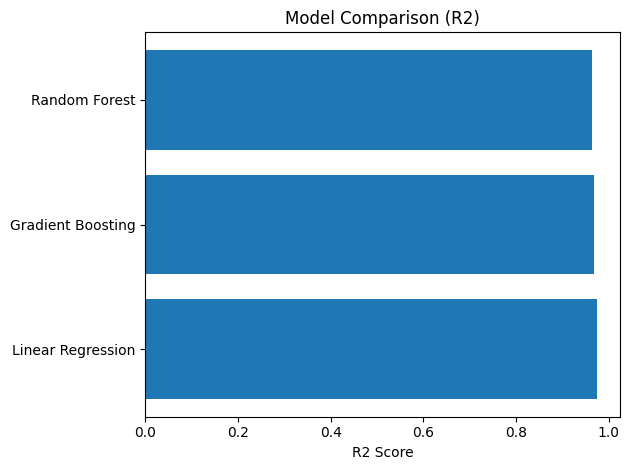

In [56]:
print("RQ2")


# =============================
# IMPORTS
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# =============================
# LOAD DATA
# =============================
df = pd.read_csv('/kaggle/input/datasets/kesinisoujanya/airline-flight-delay-dataset-100k-records/flights.csv')

# =============================
# CLEANING
# =============================
df.columns = df.columns.str.strip().str.lower()

# Drop useless columns
df = df.drop(columns=['unnamed: 27', 'cancellation_code'], errors='ignore')

# Remove duplicates
df = df.drop_duplicates()

# Remove invalid rows
df = df[df['cancelled'] == 0]
df = df[df['diverted'] == 0]

# Remove missing target
df = df.dropna(subset=['arr_delay'])

# Speed (optional)
df = df.sample(30000, random_state=42)

# =============================
# FEATURE ENGINEERING
# =============================
df['fl_date'] = pd.to_datetime(df['fl_date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['fl_date'])

df['day_of_week'] = df['fl_date'].dt.dayofweek
df['month'] = df['fl_date'].dt.month
df['dep_hour'] = df['crs_dep_time'] // 100

df['is_peak_season'] = df['month'].isin([6, 7, 12]).astype(int)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Drop original date
df = df.drop(columns=['fl_date'], errors='ignore')

# Remove leakage
df = df.drop(columns=[
    'arr_time', 'wheels_on', 'actual_elapsed_time', 'air_time'
], errors='ignore')

# =============================
# FEATURES / TARGET
# =============================
target = 'arr_delay'

X = df.drop(columns=[target])
y = df[target]

# =============================
# PREPROCESSING
# =============================
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

# =============================
# SPLIT
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# METRICS
# =============================
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

# =============================
# MODELS (FAST + STRONG)
# =============================
models = {
    "Linear Regression": LinearRegression(),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        max_depth=3
    )
}

# =============================
# TRAIN & EVALUATE
# =============================
results = []

for name, model in models.items():
    
    print(f"Training {name}...")
    
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    metrics = evaluate(y_test, preds)
    metrics['Model'] = name
    results.append(metrics)

# =============================
# RESULTS TABLE
# =============================
df_results = pd.DataFrame(results)

# Sort for clarity
df_results = df_results.sort_values(by='R2', ascending=False)

print("\nModel Comparison:\n", df_results)

df_results.to_csv("table2_model_comparison.csv", index=False)

# =============================
# PLOT
# =============================
plt.figure()
plt.barh(df_results['Model'], df_results['R2'])
plt.title("Model Comparison (R2)")
plt.xlabel("R2 Score")
plt.tight_layout()
plt.savefig("figure2_model_comparison.pdf")
plt.show()

RQ3
Running Raw strategy...
Running Scaled strategy...
        MAE      RMSE        R2 Strategy
1  6.927459  9.449810  0.962970   Scaled
0  6.941031  9.509066  0.962504      Raw


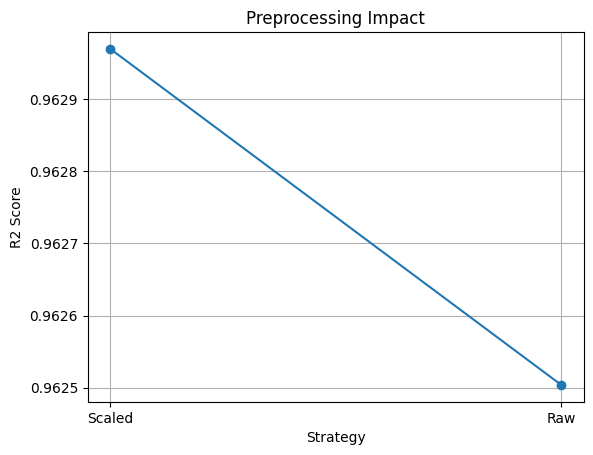

In [57]:
print("RQ3")

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

strategies = ["Raw", "Scaled"]

results = []

for strat in strategies:
    
    if strat == "Raw":
        prep = ColumnTransformer([
            # Handle categorical
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]), cat_cols),
            
            # Handle numeric (ONLY imputation, no scaling)
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]), num_cols)
        ])
        
    else:
        # Your existing full preprocessing (impute + scale)
        prep = preprocessor
    
    pipe = Pipeline([
        ('prep', prep),
        ('model', RandomForestRegressor(
            n_estimators=50,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    print(f"Running {strat} strategy...")
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    metrics = evaluate(y_test, preds)
    metrics['Strategy'] = strat
    results.append(metrics)

# =============================
# RESULTS
# =============================
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='R2', ascending=False)

print(df_results)

df_results.to_csv("table3_preprocessing.csv", index=False)

# =============================
# PLOT
# =============================
plt.figure()
plt.plot(df_results['Strategy'], df_results['R2'], marker='o')
plt.title("Preprocessing Impact")
plt.xlabel("Strategy")
plt.ylabel("R2 Score")
plt.grid()
plt.savefig("figure3_preprocessing.pdf")
plt.show()

RQ4


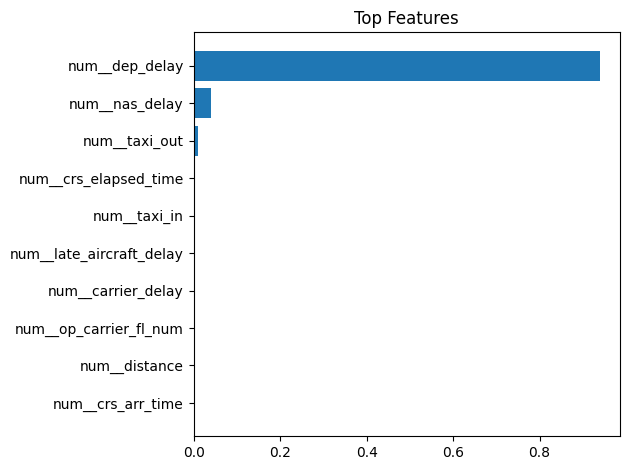

In [58]:
print("RQ4")


# =============================
# LIMIT DATA (ADD THIS)
# =============================
df_sample = df.sample(15000, random_state=42)

# =============================
# FEATURES & TARGET (USE SAMPLE)
# =============================
X = df_sample.drop(columns=[target])
y = df_sample[target]

# =============================
# SPLIT
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# MODEL PIPELINE
# =============================
from sklearn.ensemble import RandomForestRegressor

pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=50,   # faster
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ))
])

pipe.fit(X_train, y_train)

# =============================
# FEATURE IMPORTANCE
# =============================
model = pipe.named_steps['model']
feature_names = pipe.named_steps['prep'].get_feature_names_out()

importance = model.feature_importances_

df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False).head(10)

df_imp.to_csv("table4_feature_importance.csv", index=False)

# =============================
# PLOT
# =============================
plt.figure()
plt.barh(df_imp['Feature'], df_imp['Importance'])
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.tight_layout()
plt.savefig("figure4_feature_importance.pdf")
plt.show()

RQ5


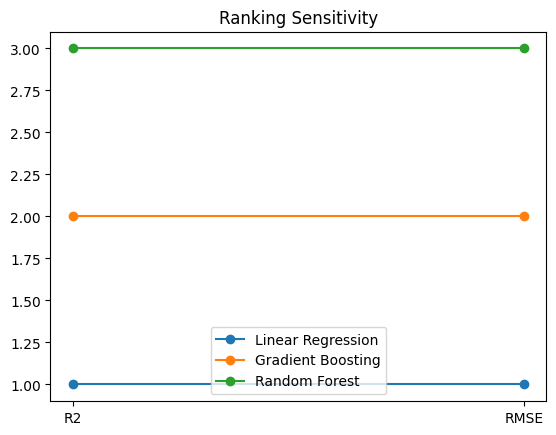

In [59]:
print("RQ5")


df = pd.read_csv("table2_model_comparison.csv")

df['Rank_R2'] = df['R2'].rank(ascending=False)
df['Rank_RMSE'] = df['RMSE'].rank()

df.to_csv("table5_metric_sensitivity.csv", index=False)

plt.figure()

for i in range(len(df)):
    plt.plot(['R2', 'RMSE'], 
             [df.loc[i, 'Rank_R2'], df.loc[i, 'Rank_RMSE']], 
             marker='o', label=df.loc[i, 'Model'])

plt.legend()
plt.title("Ranking Sensitivity")
plt.savefig("figure5_metric_sensitivity.pdf")
plt.show()

In [60]:
print("RQ6")


from sklearn.model_selection import cross_val_score

# =============================
# SAMPLE FROM X, y (NOT df)
# =============================
sample_size = min(15000, len(X))

X_sample = X.sample(sample_size, random_state=42)
y_sample = y.loc[X_sample.index]

# =============================
# PIPELINE
# =============================
pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=50,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ))
])

# =============================
# CROSS-VALIDATION
# =============================
scores = cross_val_score(
    pipe,
    X_sample,
    y_sample,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Mean R2:", scores.mean())
print("Std R2:", scores.std())

RQ6
Mean R2: 0.9569639003529533
Std R2: 0.006002697222200615


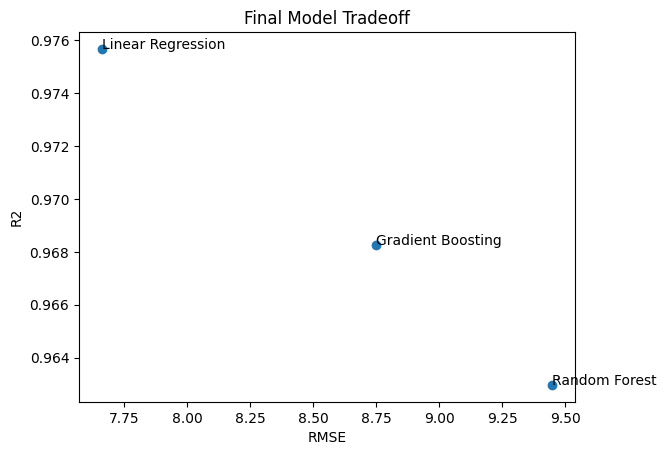

In [61]:
print("RQ7")

df = pd.read_csv("table2_model_comparison.csv")

# Normalize scores
df['Score'] = df['R2'] - df['RMSE']/df['RMSE'].max()

df.to_csv("table7_final_decision.csv", index=False)

plt.figure()
plt.scatter(df['RMSE'], df['R2'])

for i in range(len(df)):
    plt.text(df['RMSE'][i], df['R2'][i], df['Model'][i])

plt.xlabel("RMSE")
plt.ylabel("R2")
plt.title("Final Model Tradeoff")
plt.savefig("figure7_tradeoff.pdf")
plt.show()